# Table Access Protocol (TAP) moving objects
Ref: [TAP](https://dp1.lsst.io/tutorials/notebook/102/notebook-102-3.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lsst.rsp import get_tap_service, retrieve_query
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_symbols)

service = get_tap_service("tap")
assert service is not None


In [2]:
queries = pd.DataFrame(columns=['select', 'from', 'join', 'on', 'where', 'order by'])
queries.loc['sss'] = ["diaSourceId, heliocentricX, heliocentricY",
                        "dp1.SSSource", "", "", "", ""]
queries.loc['dias']  = ["diaSourceId, midpointMjdTai", 
                       "dp1.DiaSource", "", "", "ssObjectId = 21163620217073748", ""]
queries.loc['join'] = ["sss.heliocentricX, sss.heliocentricY, dias.midpointMjdTai", 
                       "dp1.SSSource as sss", 
                       "dp1.DiaSource as dias",
                       "dias.diaSourceId = sss.diaSourceId",
                       "sss.ssObjectId = 21163620217073748", 
                       "dias.midpointMjdTai ASC"]
cols = queries.columns
queries

,select,from,join,on,where,order by
sss,"diaSourceId, heliocentricX, heliocentricY",dp1.SSSource,,,,
dias,"diaSourceId, midpointMjdTai",dp1.DiaSource,,,ssObjectId = 21163620217073748,
join,"sss.heliocentricX, sss.heliocentricY, dias.mid...",dp1.SSSource as sss,dp1.DiaSource as dias,dias.diaSourceId = sss.diaSourceId,sss.ssObjectId = 21163620217073748,dias.midpointMjdTai ASC


In [3]:
def grabout():
    for idx, dat in queries.iterrows():
        query = ''
        for col in cols: 
            if dat[col] != '':
                query += f' {col.upper()} {dat[col]}'
        print(idx); print(query)
        if 'schema' not in dat['from']:
            job = service.submit_job(query)
            job.run()
            job.wait(phases=['COMPLETED', 'ERROR'])
            if job.phase == 'ERROR':
                job.raise_if_error()
            elif job.phase == 'COMPLETED':
                out = job.fetch_result().to_table()
        else:
            out = service.search(query).to_table()
        queries.loc[idx, 'out'] = out
        queries.loc[idx, 'url'] = job.url
        print(type(out), len(out))
#       display(out)
        print()
grabout()

sss
 SELECT diaSourceId, heliocentricX, heliocentricY FROM dp1.SSSource
<class 'astropy.table.table.Table'> 5988

dias
 SELECT diaSourceId, midpointMjdTai FROM dp1.DiaSource WHERE ssObjectId = 21163620217073748
<class 'astropy.table.table.Table'> 133

join
 SELECT sss.heliocentricX, sss.heliocentricY, dias.midpointMjdTai FROM dp1.SSSource as sss JOIN dp1.DiaSource as dias ON dias.diaSourceId = sss.diaSourceId WHERE sss.ssObjectId = 21163620217073748 ORDER BY dias.midpointMjdTai ASC
<class 'astropy.table.table.Table'> 133



In [4]:
queries.loc['join', 'out']

heliocentricX,heliocentricY,midpointMjdTai
AU,AU,
float32,float32,float64
0.88296497,1.6981955,60650.208053304406
0.8829369,1.6982139,60650.2107998032
0.8826996,1.6983703,60650.234026498736
0.8826319,1.698415,60650.24065655671
0.8825892,1.6984432,60650.24482964113
0.8825676,1.6984575,60650.24695128484
0.87393516,1.7041128,60651.09060258111
0.87392664,1.7041183,60651.09143349527


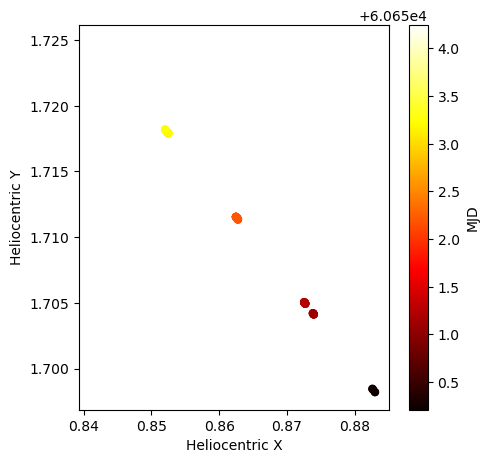

In [5]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(queries.loc['join', 'out']['heliocentricX'],
            queries.loc['join', 'out']['heliocentricY'],
            c=queries.loc['join', 'out']['midpointMjdTai'],
            cmap='hot', edgecolors='none')
plt.xlabel('Heliocentric X')
plt.ylabel('Heliocentric Y')
plt.colorbar(label='MJD')

In [6]:
df = retrieve_query(queries.loc['join', 'url']).fetch_result().to_table().to_pandas()
df

,heliocentricX,heliocentricY,midpointMjdTai
0,0.882965,1.698195,60650.208053
1,0.882937,1.698214,60650.210800
2,0.882700,1.698370,60650.234026
3,0.882632,1.698415,60650.240657
4,0.882589,1.698443,60650.244830
...,...,...,...
128,0.841458,1.724795,60654.242506
129,0.841454,1.724797,60654.242903
130,0.841424,1.724816,60654.245822
131,0.841420,1.724818,60654.246213


In [7]:
queries.loc['join', 'out'].to_pandas()

,heliocentricX,heliocentricY,midpointMjdTai
0,0.882965,1.698195,60650.208053
1,0.882937,1.698214,60650.210800
2,0.882700,1.698370,60650.234026
3,0.882632,1.698415,60650.240657
4,0.882589,1.698443,60650.244830
...,...,...,...
128,0.841458,1.724795,60654.242506
129,0.841454,1.724797,60654.242903
130,0.841424,1.724816,60654.245822
131,0.841420,1.724818,60654.246213
